In [1]:
"""
Compute a monthly climatology from the BATS zooplankton biomass dataset.

This script processes zooplankton tow data collected at the Bermuda
Atlantic Time‑series Study (BATS).  Each row in the input CSV
corresponds to a single net tow with associated wet and dry weight
biomass measurements for five size fractions (200–500 µm, 500–1000 µm,
1000–2000 µm, 2000–5000 µm and > 5000 µm).  The tow depth and volume
filtered are recorded.  To create a vertical, time‑resolved climatology,
the script:

* Converts the ``ISO_datetime`` column to pandas ``datetime`` and
  extracts the calendar month.
* Snaps the tow maximum depth to a fixed grid (default 0–300 m at 10 m
  resolution) within a tolerance (default ±5 m).
* Computes biomass concentrations (mg m⁻³) for each size class by
  dividing the wet and dry weights by the volume of water filtered.
* Aggregates the data by month and depth to calculate the mean biomass
  for each size class across all years.

The resulting climatology is returned as an ``xarray.Dataset`` with
dimensions ``month`` and ``depth``.  Each variable is named
``wetwt_xxxx`` or ``drywt_xxxx`` to reflect the size fraction; values
represent mg of biomass per cubic metre.

"""

from __future__ import annotations

import io
import warnings
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import xarray as xr
import requests

__all__ = [
    'STANDARD_DEPTHS',
    'DEPTH_TOLERANCE',
    'download_zooplankton_data',
    'preprocess_zooplankton',
    'compute_monthly_climatology',
    'build_zooplankton_climatology',
]

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [2]:

# Define a standard depth grid (in metres) appropriate for the BATS pigment
# dataset.  BATS pigment casts usually sample 12 depths between 0 and
# roughly 250 m.  Here we adopt a 10 m resolution up to 300 m, which is
# flexible enough to accommodate occasional deeper samples.  Adjust this
# array if you wish to alter the vertical resolution or range.
STANDARD_DEPTHS: np.ndarray = np.arange(0, 301, 20)

# Maximum difference (in metres) allowed when matching observed depths to
# ``STANDARD_DEPTHS``.  If the absolute difference between an observed
# depth and the nearest standard depth exceeds this value, the sample is
# discarded.  Increase this tolerance to retain more data, or decrease it
# to enforce stricter matching.
DEPTH_TOLERANCE: float = 10.0


### DOWNLOAD

In [3]:
def download_zooplankton_data(url_or_path: str) -> pd.DataFrame:
    """Download or read the zooplankton dataset into a DataFrame.

    Parameters
    ----------
    url_or_path : str
        URL pointing to a CSV file or a local file path.

    Returns
    -------
    pandas.DataFrame
        Raw zooplankton dataset.  Returns empty DataFrame if unable
        to download or read the file.
    """
    try:
        if url_or_path.startswith(('http://', 'https://')):
            resp = requests.get(url_or_path, timeout=60)
            resp.raise_for_status()
            content = resp.content
            return pd.read_csv(io.BytesIO(content), dtype=str)
        else:
            return pd.read_csv(url_or_path, dtype=str)
    except Exception as exc:
        warnings.warn(f"Failed to load zooplankton data from {url_or_path}: {exc}")
        return pd.DataFrame()


### PROCESS

In [4]:
def preprocess_zooplankton(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess the raw zooplankton DataFrame.

    Operations performed:

    * Parse ISO 8601 date strings from ``ISO_datetime``.
    * Extract calendar month indices (1–12).
    * Convert the ``depth`` column (maximum tow depth) to floats and
      assign each sample to the nearest standard depth if within
      ``DEPTH_TOLERANCE``.
    * Convert the ``vol_filt`` column (volume filtered, m³) to floats.
    * Identify wet and dry weight columns and compute biomass
      concentrations by dividing each by ``vol_filt``.
    * Return a tidy DataFrame containing ``month``, ``depth`` and one
      column per size‑fraction biomass concentration.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw zooplankton dataset.

    Returns
    -------
    pandas.DataFrame
        Tidy DataFrame with concentration columns (mg m⁻³).  If
        preprocessing fails, returns an empty DataFrame.
    """
    if df.empty:
        return df

    # Parse ISO date/time
    if 'ISO_datetime' not in df.columns:
        warnings.warn("Column 'ISO_datetime' not found in zooplankton data; cannot parse dates.")
        return pd.DataFrame()
    df['datetime'] = pd.to_datetime(df['ISO_datetime'], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month

    # Depth handling
    if 'depth' not in df.columns:
        warnings.warn("No 'depth' column found in zooplankton data.")
        return pd.DataFrame()
    df['depth_orig'] = pd.to_numeric(df['depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    # Snap to standard grid
    idxs = np.abs(df['depth_orig'].values[:, None] - STANDARD_DEPTHS[None, :]).argmin(axis=1)
    snapped_depths = STANDARD_DEPTHS[idxs]
    within = np.abs(df['depth_orig'] - snapped_depths) <= DEPTH_TOLERANCE
    df = df.loc[within].copy()
    df['depth'] = snapped_depths[within.values]

    # Volume filtered
    if 'vol_filt' not in df.columns:
        warnings.warn("No 'vol_filt' column found in zooplankton data; cannot compute concentrations.")
        return pd.DataFrame()
    df['vol_filt'] = pd.to_numeric(df['vol_filt'], errors='coerce')
    df.dropna(subset=['vol_filt'], inplace=True)

    # Identify biomass columns
    wet_cols = [col for col in df.columns if col.startswith('wetwt_')]
    dry_cols = [col for col in df.columns if col.startswith('drywt_')]

    # Convert weight to concentration (mg per m3) and rename variables
    for col in wet_cols + dry_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # divide by volume filtered; handle zero volume gracefully
        with np.errstate(divide='ignore', invalid='ignore'):
            df[col] = df[col] / df['vol_filt']

    # Build tidy output
    tidy_cols = ['month', 'depth'] + wet_cols + dry_cols
    return df[tidy_cols]


### CLIMATOLOGY

In [5]:
def compute_monthly_climatology(df: pd.DataFrame, variables: Iterable[str]) -> xr.Dataset:
    """Aggregate zooplankton data into a monthly climatology.

    Parameters
    ----------
    df : pandas.DataFrame
        Tidy DataFrame with columns ``month``, ``depth`` and biomass
        concentration variables (mg m⁻³).
    variables : Iterable[str]
        List of variable names to process.

    Returns
    -------
    xarray.Dataset
        Dataset with dimensions ``month`` and ``depth`` containing the
        mean biomass concentration for each size fraction across all
        years.
    """
    months = np.arange(1, 13)
    depths = STANDARD_DEPTHS.copy()
    data_vars = {}
    for var in variables:
        if var not in df.columns:
            continue
        pivot = df.pivot_table(index='month', columns='depth', values=var, aggfunc='mean')
        pivot = pivot.reindex(index=months, columns=depths)
        data_vars[var] = (('month', 'depth'), pivot.values.astype(float))
    ds = xr.Dataset(
        data_vars=data_vars,
        coords={'month': months, 'depth': depths},
        attrs={'description': 'Monthly climatology of BATS zooplankton biomass concentrations on a fixed depth grid',
               'units': 'mg m^-3'}
    )
    return ds



### BUILD

In [6]:
def build_zooplankton_climatology(url_or_path: str, depth_grid: Optional[np.ndarray] = None) -> xr.Dataset:
    """Download, preprocess and compute a monthly climatology for zooplankton biomass.

    Parameters
    ----------
    url_or_path : str
        URL or local path to the zooplankton CSV file.
    depth_grid : array-like of float, optional
        Override the default depth grid.  Use this to customise the
        vertical resolution or range.  If provided, ``STANDARD_DEPTHS``
        will be replaced by this array (converted to floats).

    Returns
    -------
    xarray.Dataset
        Monthly climatology dataset with variables for each size
        fraction wet and dry weight biomass concentration (mg m⁻³).
    """
    global STANDARD_DEPTHS
    if depth_grid is not None:
        STANDARD_DEPTHS = np.asarray(depth_grid, dtype=float)
    raw = download_zooplankton_data(url_or_path)
    tidy = preprocess_zooplankton(raw)
    if tidy.empty:
        raise RuntimeError("No valid zooplankton data after preprocessing.")
    variables = [col for col in tidy.columns if col not in ('month', 'depth')]
    return compute_monthly_climatology(tidy, variables)



### call

In [7]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/881861/file/yp3k5kBir5GMvR/881861_v7_bats_zooplankton_biomass.csv"
ds = build_zooplankton_climatology(link)
print(ds)


<xarray.Dataset> Size: 16kB
Dimensions:     (month: 12, depth: 16)
Coordinates:
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth       (depth) int64 128B 0 20 40 60 80 100 ... 200 220 240 260 280 300
Data variables:
    wetwt_0200  (month, depth) float64 2kB nan nan nan nan ... nan 1.928 nan
    wetwt_0500  (month, depth) float64 2kB nan nan nan nan ... nan 3.157 nan
    wetwt_1000  (month, depth) float64 2kB nan nan nan nan ... nan 1.875 nan
    wetwt_2000  (month, depth) float64 2kB nan nan nan nan ... nan 1.699 nan
    wetwt_5000  (month, depth) float64 2kB nan nan nan nan ... nan 1.976 nan
    drywt_0200  (month, depth) float64 2kB nan nan nan nan ... nan 0.3015 nan
    drywt_0500  (month, depth) float64 2kB nan nan nan nan ... nan 0.4692 nan
    drywt_1000  (month, depth) float64 2kB nan nan nan nan ... nan 0.4154 nan
    drywt_2000  (month, depth) float64 2kB nan nan nan nan ... nan 0.3401 nan
    drywt_5000  (month, depth) float64 2kB nan nan nan nan ... na

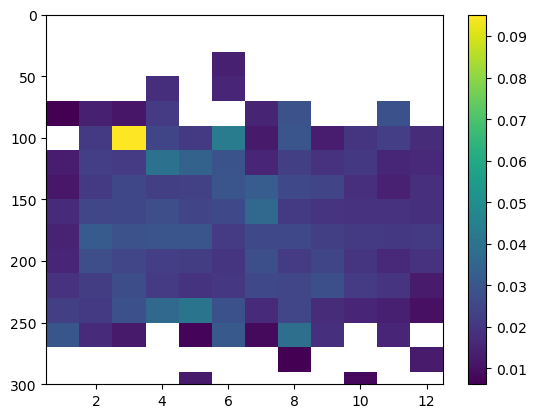

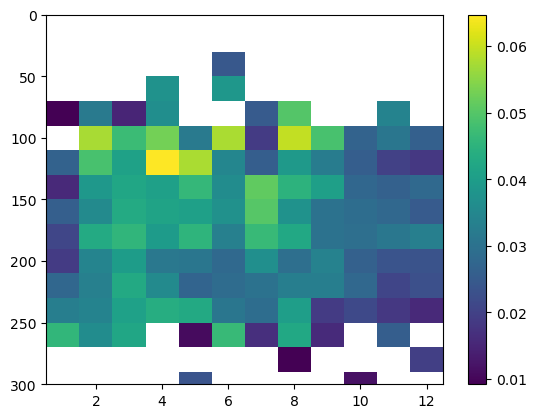

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['drywt_0200'].T / 12 * 0.5)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['drywt_0500'].T / 12 * 0.5)
plt.ylim(300,0)
plt.colorbar()



### SAVE

In [12]:
%%time
    
ds.to_netcdf('./bats_zooplankton_monthly_climatology.nc')

CPU times: user 269 ms, sys: 94.9 ms, total: 363 ms
Wall time: 1.15 s
